In [4]:
import pandas as pd

In [6]:
df = pd.read_csv("../archive/data.csv")

In [7]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [9]:
df = df.drop(columns=["id", "Unnamed: 32"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [11]:
df["diagnosis"] = df["diagnosis"].map({
    "M": 1,
    "B": 0
})


In [12]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [13]:
X = df.drop(columns=["diagnosis"])

y = df["diagnosis"]

In [14]:
print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [15]:
df = df.sample(frac=1, random_state=42)

In [16]:
df = df.reset_index(drop=True)

In [17]:
train_size = int(0.8 * len(df))

In [18]:
train_df = df[:train_size]
test_df = df[train_size:]

In [19]:
X_train = train_df.drop(columns=["diagnosis"])
y_train = train_df["diagnosis"]

X_test = test_df.drop(columns=["diagnosis"])
y_test = test_df["diagnosis"]

In [20]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(455, 30)
(114, 30)
(455,)
(114,)


In [21]:
train_mean = X_train.mean()

In [22]:
train_std = X_train.std()

In [23]:
X_train = (X_train - train_mean) / train_std

X_test = (X_test - train_mean) / train_std

In [24]:
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,-0.454628,-0.169611,-0.432765,-0.486779,0.239073,0.020759,-0.110008,-0.267132,0.398003,0.106758,...,-0.256520,-0.183900,-0.324243,-0.351201,0.458375,-0.110609,-0.027633,-0.185340,0.164277,0.191312
1,1.403253,0.476556,1.335044,1.422857,-0.446475,-0.033542,0.237277,0.794111,-0.819161,-1.186798,...,1.799651,0.141212,1.757294,1.788040,-0.573944,-0.137733,-0.020013,0.991563,-0.571736,-1.015479
2,0.403960,0.040215,0.424317,0.299940,0.923904,0.329715,0.716890,0.829057,0.419294,-0.711643,...,0.635389,0.044014,0.535490,0.509645,0.990042,-0.100277,0.505717,0.573413,-0.117093,-0.216908
3,-0.474729,-0.388974,-0.416962,-0.528325,0.651406,0.503854,-0.142811,-0.529745,-0.006536,1.140753,...,-0.691039,-0.473819,-0.516155,-0.643071,0.564709,0.051487,-0.155256,-0.608053,-0.563788,0.531403
4,-0.721681,-1.161512,-0.700577,-0.719554,0.252698,0.136852,-0.267560,-0.582421,0.018304,0.686873,...,-0.819940,-1.015114,-0.838891,-0.747504,0.099500,-0.278518,-0.443836,-0.676781,-0.924641,-0.152688


In [25]:
import math

In [26]:
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

In [27]:
def predict_row(features, weights, bias):

    z = 0

    for i in range(len(features)):
        z += features[i] * weights[i]

    z += bias

    return sigmoid(z)

In [28]:
n_features = len(X_train.columns)

In [29]:
weights = [0] * n_features


In [30]:
bias = 0

In [31]:
print(len(weights))
print(bias)


30
0


In [32]:
def binary_cross_entropy(y_true, y_pred):

    epsilon = 1e-15

    y_pred = max(epsilon, min(y_pred, 1 - epsilon))

    loss = -(
        y_true * math.log(y_pred)
        +
        (1 - y_true) * math.log(1 - y_pred)
    )

    return loss

In [33]:
print(binary_cross_entropy(1, 0.99))
print(binary_cross_entropy(1, 0.01))

0.01005033585350145
4.605170185988091


In [34]:
first_row = X_train.iloc[0].tolist()

actual_label = y_train.iloc[0]

In [35]:
prediction = predict_row(first_row, weights, bias)

print(prediction)

0.5


In [36]:
error = prediction - actual_label

print(error)

0.5


In [39]:
learning_rate = 0.01

In [40]:
for i in range(len(weights)):

    gradient = error * first_row[i]

    weights[i] = weights[i] - learning_rate * gradient

In [41]:
print(weights[:5])

print(bias)

[np.float64(0.004546284788888812), np.float64(0.0016961060768907422), np.float64(0.004327648415944803), np.float64(0.0048677921456703865), np.float64(-0.002390734396645557)]
0


In [42]:
learning_rate = 0.01

epochs = 100

In [43]:
loss_history = []

In [44]:
%%time
for epoch in range(epochs):

    total_loss = 0

    for row_index in range(len(X_train)):

        features = X_train.iloc[row_index].tolist()

        actual_label = y_train.iloc[row_index]

        prediction = predict_row(features, weights, bias)

        loss = binary_cross_entropy(actual_label, prediction)

        total_loss += loss

        error = prediction - actual_label

        for i in range(len(weights)):

            gradient = error * features[i]

            weights[i] = (
                weights[i]
                -
                learning_rate * gradient
            )

        bias = bias - learning_rate * error

    average_loss = total_loss / len(X_train)

    loss_history.append(average_loss)

    print(
        "Epoch:",
        epoch + 1,
        "Loss:",
        average_loss
    )

Epoch: 1 Loss: 0.21225952186033212
Epoch: 2 Loss: 0.11052727133836561
Epoch: 3 Loss: 0.09143365741304413
Epoch: 4 Loss: 0.08197005908098387
Epoch: 5 Loss: 0.07608963831839907
Epoch: 6 Loss: 0.07199579420971704
Epoch: 7 Loss: 0.0689397312578759
Epoch: 8 Loss: 0.06654734764899281
Epoch: 9 Loss: 0.06460868962482837
Epoch: 10 Loss: 0.06299586829872357
Epoch: 11 Loss: 0.0616260690112287
Epoch: 12 Loss: 0.06044305258315287
Epoch: 13 Loss: 0.059407143562173366
Epoch: 14 Loss: 0.05848946340207918
Epoch: 15 Loss: 0.057668436577065295
Epoch: 16 Loss: 0.05692758321470771
Epoch: 17 Loss: 0.05625407435429635
Epoch: 18 Loss: 0.05563775730777856
Epoch: 19 Loss: 0.055070480699998474
Epoch: 20 Loss: 0.05454561620156081
Epoch: 21 Loss: 0.05405771270601212
Epoch: 22 Loss: 0.053602241731970965
Epoch: 23 Loss: 0.05317540694066115
Epoch: 24 Loss: 0.052773999539398604
Epoch: 25 Loss: 0.052395287066068844
Epoch: 26 Loss: 0.05203692682046822
Epoch: 27 Loss: 0.051696897741395825
Epoch: 28 Loss: 0.05137344626045

In [45]:
test_predictions = []

test_probabilities = []

In [46]:
for row_index in range(len(X_test)):

    features = X_test.iloc[row_index].tolist()

    probability = predict_row(
        features,
        weights,
        bias
    )

    test_probabilities.append(probability)

    if probability >= 0.5:
        predicted_class = 1
    else:
        predicted_class = 0

    test_predictions.append(predicted_class)

In [47]:
correct = 0

In [48]:
for i in range(len(y_test)):

    actual = y_test.iloc[i]

    predicted = test_predictions[i]

    if actual == predicted:
        correct += 1

In [49]:
accuracy = correct / len(y_test)

print("Accuracy:", accuracy)

Accuracy: 0.9649122807017544


In [50]:
TP = 0
TN = 0
FP = 0
FN = 0

In [51]:
for i in range(len(y_test)):

    actual = y_test.iloc[i]

    predicted = test_predictions[i]

    if actual == 1 and predicted == 1:
        TP += 1

    elif actual == 0 and predicted == 0:
        TN += 1

    elif actual == 0 and predicted == 1:
        FP += 1

    elif actual == 1 and predicted == 0:
        FN += 1

In [52]:
print("True Positives :", TP)
print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)

True Positives : 44
True Negatives : 66
False Positives: 1
False Negatives: 3


In [53]:
precision = TP / (TP + FP)

print("Precision:", precision)

Precision: 0.9777777777777777


In [54]:
recall = TP / (TP + FN)

print("Recall:", recall)

Recall: 0.9361702127659575


In [55]:
f1_score = (
    2 * precision * recall
    /
    (precision + recall)
)

print("F1 Score:", f1_score)

F1 Score: 0.9565217391304347


In [56]:
import time

In [57]:
start_time = time.time()

In [58]:
import matplotlib.pyplot as plt


In [59]:
confusion_matrix = [
    [TP, FN],
    [FP, TN]
]

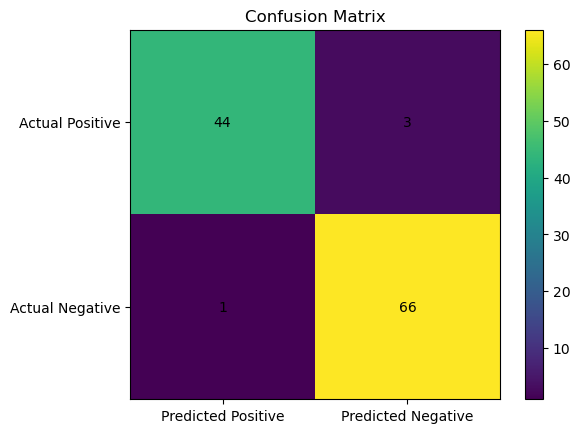

In [60]:
plt.imshow(confusion_matrix)

plt.colorbar()

plt.xticks([0, 1], ["Predicted Positive", "Predicted Negative"])

plt.yticks([0, 1], ["Actual Positive", "Actual Negative"])

plt.title("Confusion Matrix")

plt.text(0, 0, TP, ha='center', va='center')
plt.text(1, 0, FN, ha='center', va='center')
plt.text(0, 1, FP, ha='center', va='center')
plt.text(1, 1, TN, ha='center', va='center')

plt.show()

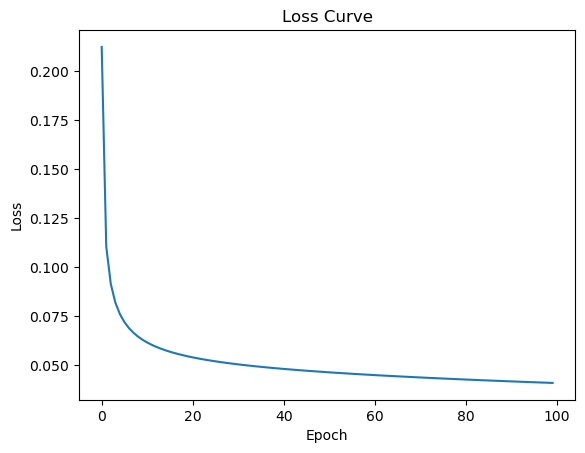

In [61]:
plt.plot(loss_history)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.show()